In [2]:
import pandas as pd
import numpy as np
import random
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import joblib

In [3]:
import pandas as pd
import random

malicious_patterns = [
    "../../etc/passwd",
    "../etc/shadow",
    "../../../secret.txt",
    "../../windows/system32",
    "../../../../etc/passwd"
]

safe_patterns = [
    "index.html",
    "images/logo.png",
    "css/style.css",
    "js/app.js",
    "home/user/file.txt"
]

data = []

# Generate malicious samples
for _ in range(500):
    text = random.choice(malicious_patterns)
    data.append([text, 1])

# Generate safe samples
for _ in range(500):
    text = random.choice(safe_patterns)
    data.append([text, 0])

df = pd.DataFrame(data, columns=["input", "label"])
df.head()

,input,label
0,../../../secret.txt,1
1,../../../secret.txt,1
2,../../etc/passwd,1
3,../../../../etc/passwd,1
4,../../../secret.txt,1


In [5]:
def extract_features(text):
    return {
        "has_dotdot": int("../" in text),
        "num_slashes": text.count("/"),
        "length": len(text),
        "has_sensitive": int("etc" in text or "passwd" in text or "shadow" in text)
    }

features = df['input'].apply(lambda x: pd.Series(extract_features(x)))
df = pd.concat([df, features], axis=1)
df.head()

,input,label,has_dotdot,num_slashes,length,has_sensitive
0,../../../secret.txt,1,1,3,19,0
1,../../windows/system32,1,1,3,22,0
2,../../../secret.txt,1,1,3,19,0
3,../../../secret.txt,1,1,3,19,0
4,../../etc/passwd,1,1,3,16,1


In [6]:
X = df[['has_dotdot', 'num_slashes', 'length', 'has_sensitive']]
y = df['label']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest:\n")
print(classification_report(y_test, y_pred))

Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        96

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [9]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        96

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



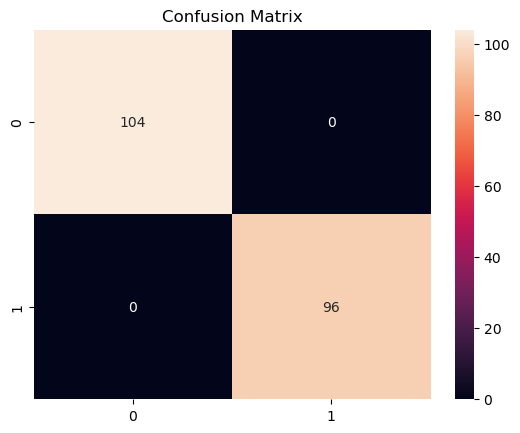

In [10]:
os.makedirs("Images", exist_ok=True)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")

plt.savefig("Images/confusion_matrix.png")
plt.show()

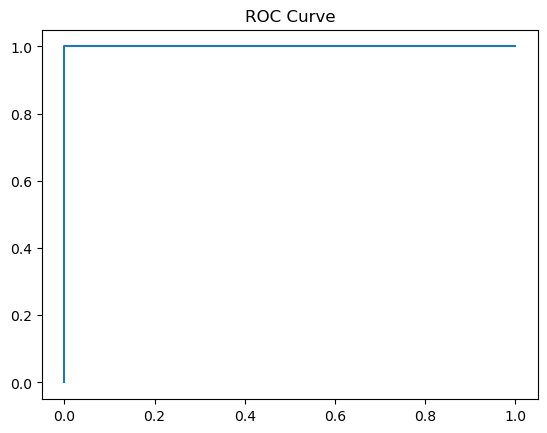

In [11]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title("ROC Curve")

plt.savefig("Images/roc_curve.png")
plt.show()

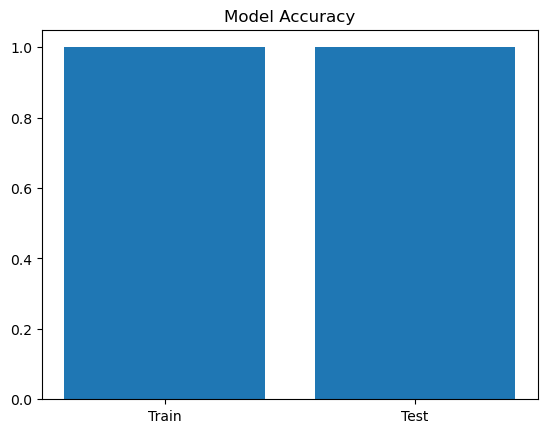

In [12]:
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("Model Accuracy")

plt.savefig("Images/accuracy.png")
plt.show()

In [13]:
joblib.dump(rf, "model.pkl")

['model.pkl']